In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv("European_Bank .csv")
df

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df["Exited"].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop(["CustomerId", "Surname", "Year"], axis=1, errors="ignore")
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [12]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [13]:
print((df["Balance"] == 0).sum())  # how many zeros?

3617


In [14]:
print(df["NumOfProducts"].value_counts())

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [15]:

#  Handle age outliers
df = df[df["Age"] <= 80]

# Investigate zero balances
print((df["Balance"] == 0).sum())


#  Note class imbalance for modeling
print(df["Exited"].value_counts(normalize=True))

3611
Exited
0    0.796155
1    0.203845
Name: proportion, dtype: float64


In [16]:
# Should only contain 0 and 1
print(df["HasCrCard"].unique())
print(df["IsActiveMember"].unique())

# Check for nulls
print(df[["HasCrCard", "IsActiveMember"]].isnull().sum())

[1 0]
[1 0]
HasCrCard         0
IsActiveMember    0
dtype: int64


In [17]:
print(df["Tenure"].unique())
print(df["Tenure"].value_counts().sort_index())

# Check for anything outside 0–10
print(df[df["Tenure"] > 10])   # should be empty
print(df[df["Tenure"] < 0])    # should be empty

[ 2  1  8  7  4  6  3 10  5  9  0]
Tenure
0      413
1     1033
2     1047
3     1008
4      989
5     1011
6      964
7     1028
8     1023
9      984
10     488
Name: count, dtype: int64
Empty DataFrame
Columns: [CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
Index: []
Empty DataFrame
Columns: [CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
Index: []


350 850


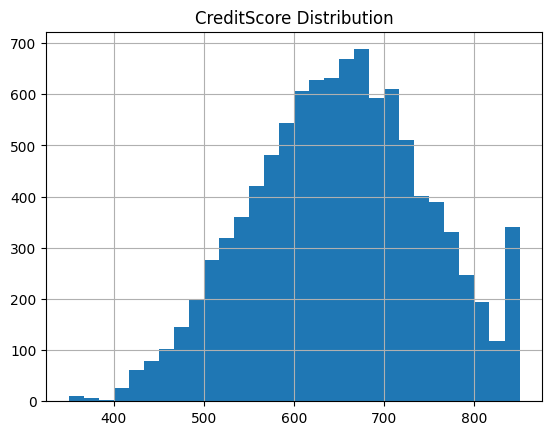

Empty DataFrame
Columns: [CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
Index: []
Empty DataFrame
Columns: [CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Exited]
Index: []


In [18]:
# Range check
print(df["CreditScore"].min(), df["CreditScore"].max())  # expect 300–850

# Spot outliers
import matplotlib.pyplot as plt
df["CreditScore"].hist(bins=30)
plt.title("CreditScore Distribution")
plt.show()

# Any impossible values?
print(df[df["CreditScore"] < 300])
print(df[df["CreditScore"]  > 850])

Exited
0    7952
1    2036
Name: count, dtype: int64
Exited
0    79.615539
1    20.384461
Name: proportion, dtype: float64


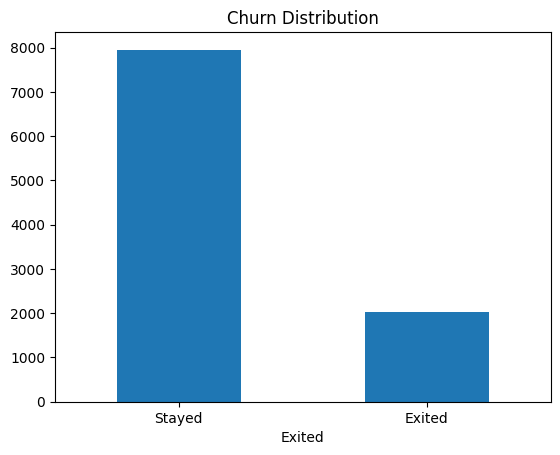

In [19]:
# Raw counts
print(df["Exited"].value_counts())

# Percentage split
print(df["Exited"].value_counts(normalize=True) * 100)

# Visualize
df["Exited"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xticks([0, 1], ["Stayed", "Exited"], rotation=0)
plt.show()

In [20]:
print(df["HasCrCard"].value_counts())
print(df["IsActiveMember"].value_counts())

HasCrCard
1    7047
0    2941
Name: count, dtype: int64
IsActiveMember
1    5140
0    4848
Name: count, dtype: int64


In [22]:
# Save cleaned dataframe as CSV
df.to_csv("1_Data_Exploration_Cleaning .csv", index=False)
print("Saved successfully!")
print(df.shape)

Saved successfully!
(9988, 11)
